In [5]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [6]:
url = "https://www.kaggle.com/competitions/playground-series-s6e3/data"
test = "test.csv"
train = "train.csv"

In [7]:
import pandas as pd
import kagglehub
import os

# 1. Download the competition dataset
# This will download the files and return the local path where they are cached
dataset_path = kagglehub.competition_download("playground-series-s6e3")
print(f"Data downloaded to: {dataset_path}")

# 2. Load the train and test CSV files into pandas DataFrames
train_df = pd.read_csv(os.path.join(dataset_path, "train.csv"))
test_df = pd.read_csv(os.path.join(dataset_path, "test.csv"))

# Show the first few rows to verify
train_df

# Check the balance of the target variable. Churn 1 is 22.5%

Data downloaded to: C:\Users\zak\.cache\kagglehub\competitions\playground-series-s6e3


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [8]:
X = train_df.drop('Churn', axis=1)
y = train_df['Churn'].values

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [10]:
# 1. Define specific transformers for each data type
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# 2. Use ColumnTransformer to apply them to the right columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', categorical_transformer, make_column_selector(dtype_include=object))
    ])

log_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

log_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [11]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

In [12]:
min_features_to_select = 1  # Minimum number of features to consider
clf = LogisticRegression()
cv = StratifiedKFold(5)

rfecv = RFECV(
    estimator=log_pipe,
    step=1,
    cv=cv,
    scoring="roc_auc",
    min_features_to_select=min_features_to_select,
    n_jobs=-1,
)
rfecv.fit(X, y)

print(f"Optimal number of features: {rfecv.n_features_}")

ValueError: could not convert string to float: 'Male'

In [7]:
from sklearn.model_selection import cross_validate

In [8]:
import pandas as pd

# Re-run with explicit flag
results = cross_validate(log_pipe, X, y, cv=5,
                         scoring='roc_auc',
                         return_train_score=True)

# Convert to DataFrame for a much cleaner view
results_df = pd.DataFrame(results)

# Now you can see everything clearly
print(results_df)

# To see just the keys if you're curious:
print("\nAvailable keys:", list(results.keys()))

   fit_time  score_time  test_score  train_score
0  2.950586    0.361887    0.909091     0.907680
1  2.561578    0.380798    0.907659     0.908038
2  2.444118    0.378403    0.907458     0.908078
3  2.478708    0.380361    0.908515     0.907866
4  2.551366    0.368808    0.907044     0.908235

Available keys: ['fit_time', 'score_time', 'test_score', 'train_score']


In [9]:
results

{'fit_time': array([2.95058632, 2.56157804, 2.44411826, 2.47870803, 2.55136561]),
 'score_time': array([0.3618865 , 0.38079786, 0.37840343, 0.38036132, 0.36880803]),
 'test_score': array([0.90909134, 0.90765864, 0.90745762, 0.90851526, 0.90704366]),
 'train_score': array([0.90768027, 0.90803835, 0.90807779, 0.9078659 , 0.90823502])}

In [10]:
log_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [11]:
test_df['Churn'] = log_pipe.predict_proba(test_df)[:, 1]

In [12]:
test_df

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50,0.052397
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50,0.000215
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55,0.116124
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15,0.003348
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65,0.485498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,848844,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.95,1443.65,0.000142
254651,848845,Male,1,Yes,No,16,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,100.15,1563.50,0.782366
254652,848846,Male,0,Yes,No,35,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),105.80,3132.75,0.239638
254653,848847,Female,0,No,No,25,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.25,511.25,0.006686


In [13]:
submission = test_df[['id', 'Churn']]
submission.to_csv('log_pipe.csv', index=False, header=True)

In [14]:
# !kaggle competitions submit -c playground-series-s6e3 -f log_pipe.csv -m "simple logistic regression baseline"

In [15]:
!kaggle competitions submissions -c playground-series-s6e3

fileName      date                        description                          status                     publicScore  privateScore  
------------  --------------------------  -----------------------------------  -------------------------  -----------  ------------  
log_pipe.csv  2026-03-18 15:22:44.420000  simple logistic regression baseline  SubmissionStatus.COMPLETE  0.90502                    
log_pipe.csv  2026-03-18 15:17:48.427000  simple logistic regression baseline  SubmissionStatus.COMPLETE  0.09497                    


After the first model, the public score is about as bad as it gets. Let's diagnose the issue.

The current best kaggle score is: 0.91758
Top 100 score is: 0.91702

AI suggests that my model is too simple and is probably underfitting. Let's add poly nomial features to the model.

In [16]:
from sklearn.preprocessing import PolynomialFeatures

In [17]:
# 1. Define specific transformers for each data type
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 2. Use ColumnTransformer to apply them to the right columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', categorical_transformer, make_column_selector(dtype_include=object))
    ])

log_poly_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("poly_features", PolynomialFeatures(2)),
    ('scaler', StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [18]:
log_poly_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [19]:
def model_results(pipeline, X, y, cv=5, sample=None):
    """
    Evaluate a pipeline using cross-validation, fit on the full (sampled) data,
    and return the sampled data and fitted model.
    """
    if sample is not None:
        if isinstance(sample, float):
            X = X.sample(frac=sample, random_state=42)
        elif isinstance(sample, int):
            X = X.sample(n=sample, random_state=42)
        y = y[X.index]

    results = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring='roc_auc',
        return_train_score=True
    )
    
    # Calculate means and standard deviations
    train_mean = results['train_score'].mean()
    train_std = results['train_score'].std()
    test_mean = results['test_score'].mean()
    test_std = results['test_score'].std()
    
    # Print formatted results
    print(f"Train Score: {train_mean:.5f} ± {train_std:.5f}")
    print(f"Test Score:  {test_mean:.5f} ± {test_std:.5f}")
    print(f"Overfit Gap: {train_mean - test_mean:.5f}")

    # Fit once on the full (sampled) dataset to be used for diagnostic plots
    pipeline.fit(X, y)

    return X, y, pipeline

In [20]:
X_sample, y_sample, log_poly_pipe = model_results(log_poly_pipe, X, y, cv = 5, sample=0.1)

Train Score: 0.91357 ± 0.00093
Test Score:  0.90965 ± 0.00367
Overfit Gap: 0.00392


In [23]:
TOP_1000 = 0.91399

In [21]:
#     fit_time  score_time  test_score  train_score
# 0  81.833390    3.755356    0.902720     0.911371
# 1  66.666082    3.779426    0.905922     0.912635

In [ ]:
# from sklearn.feature_selection import SelectFromModel
# from sklearn.model_selection import GridSearchCV
#
# # We add 'SelectFromModel' to prune the polynomial noise
# log_poly_refined = Pipeline(steps=[
#     ("preprocessor", preprocessor),
#     ("poly_features", PolynomialFeatures(2)),
#     ('scaler', StandardScaler()),
#     # This uses an L1 penalty to select only the most important features
#     ("selector", SelectFromModel(LogisticRegression(solver='liblinear', C=0.1))),
#     ("classifier", LogisticRegression(max_iter=1000))
# ])
#
# # Define a range of C values to find the best Bias-Variance balance
# param_grid = {
#     'classifier__C': [0.001, 0.01, 0.1, 1.0],
#     'classifier__penalty': ['l2'] # Keeping L2 for the final classifier
# }
#
# grid_search = GridSearchCV(log_poly_refined, param_grid, cv=5, scoring='accuracy', return_train_score=True)
# grid_search.fit(X, y)
#
# # View the results
# import pandas as pd
# results = pd.DataFrame(grid_search.cv_results_)[['param_classifier__C', 'mean_train_score', 'mean_test_score']]
# print(results)

C:\Users\zak\Projects\PyCharmProjects\data-science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\zak\Projects\PyCharmProjects\data-science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\zak\Projects\PyCharmProjects\data-science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

# 1. PREPROCESSING: Clean and Encode
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', categorical_transformer, make_column_selector(dtype_include=object))
    ])

# 2. THE MASTER PIPELINE: Attack Bias & Control Variance
full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),

    # ATTACK BIAS: Create non-linear interactions
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),

    # REQUIRED: Scale before Regularization/Selection
    ('scaler', StandardScaler()),

    # CONTROL VARIANCE: Prune the noisy interactions (L1 Selection)
    # Adjust 'C' here to be more/less aggressive in cutting features
    ("selector", SelectFromModel(
        LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
    )),

    # FINAL CLASSIFIER: The estimator
    ("classifier", LogisticRegression(max_iter=2000, C=1.0, random_state=42))
])

# 3. DIAGNOSTIC EXECUTION: Monitor the Gap
# We use cross_validate to get BOTH train and test scores
results = cross_validate(
    full_pipeline, X, y,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

# 4. REPORTING THE DIAGNOSIS
print(f"Average Train Score: {results['train_score'].mean():.5f}")
print(f"Average Test Score:  {results['test_score'].mean():.5f}")
print(f"The Variance Gap:    {results['train_score'].mean() - results['test_score'].mean():.5f}")

In [27]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# We simplify the preprocessor because HistGB handles missing values internally!
# We only need to encode categories if they aren't already numbers.
fast_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         make_column_selector(dtype_include=object))
    ], remainder='passthrough') # Keep numeric as is

hgb_pipe = Pipeline(steps=[
    ("preprocessor", fast_preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        max_depth=5,     # Controls Bias/Variance
        random_state=42
    ))
])

In [ ]:
# Run this after fitting your model
def plot_importance(pipe, X, y):
    """Requires a fitted pipeline."""
    result = permutation_importance(pipe, X, y, n_repeats=5, random_state=42)

    # Get feature names from the preprocessor
    feature_names = (pipe.named_steps['preprocessor']
                    .get_feature_names_out())

    sorted_idx = result.importances_mean.argsort()[-20:] # Top 20
    plt.barh(feature_names[sorted_idx], result.importances_mean[sorted_idx])
    plt.title("Top 20 Features (Diagnosis)")
    plt.show()

# plot_importance(hgb_pipe, X_sample, y_sample)

In [ ]:
def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training score")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation score")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.title("Learning Curve: Do we need more data?")
    plt.show()

# plot_learning_curve(hgb_pipe, X_sample, y_sample)

### 5. Experimenting with Pipeline 2 (Random Forest)
Let's try a different architecture using Random Forest to see if it captures different patterns in the data.

Evaluating Pipeline 2 (Random Forest):
Train Score: 0.93020 ± 0.00066
Test Score:  0.91011 ± 0.00369
Overfit Gap: 0.02009


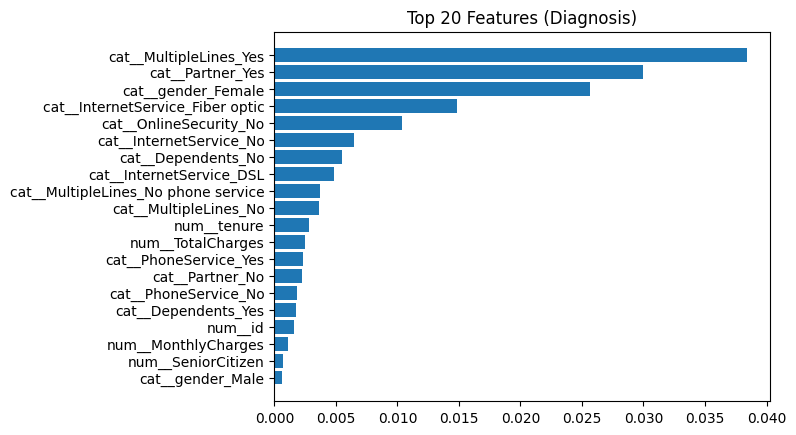

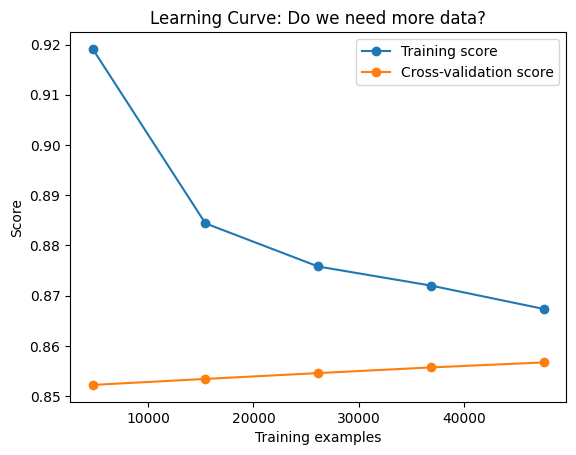

In [30]:
from sklearn.ensemble import RandomForestClassifier

# Define a new pipeline with a different model (Random Forest)
pipeline_2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# Evaluate the new pipeline
print("Evaluating Pipeline 2 (Random Forest):")
X_sample, y_sample, pipeline_2 = model_results(pipeline_2, X, y, sample=0.1)

# Diagnostic plots for the new pipeline
plot_importance(pipeline_2, X_sample, y_sample)
plot_learning_curve(pipeline_2, X_sample, y_sample)

In [24]:
train_df

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [43]:
# 1. Preprocess the data outside the RFECV
# This converts all categorical columns to numeric (one-hot encoded)
X_encoded = preprocessor.fit_transform(X)

# 2. Use the base estimator (LogisticRegression) instead of the whole pipeline
# RFECV will now work on the numeric features
rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000),
    step=1,
    cv=StratifiedKFold(5),
    scoring="roc_auc",
    min_features_to_select=1,
    n_jobs=-1,
)

rfecv.fit(X_encoded, y)

print(f"Optimal number of features: {rfecv.n_features_}")


Optimal number of features: 46


In [44]:
X_encoded

array([[-1.73204789, -0.35888538, -0.3023417 , ...,  0.        ,
         0.        ,  1.        ],
       [-1.73204206, -0.35888538,  0.85479321, ...,  1.        ,
         0.        ,  0.        ],
       [-1.73203623, -0.35888538,  0.85479321, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.73203623, -0.35888538,  1.41341006, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.73204206, -0.35888538, -0.18263809, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.73204789,  2.78640495, -1.3796742 , ...,  0.        ,
         1.        ,  0.        ]], shape=(594194, 46))